<a href="https://colab.research.google.com/github/GAURAV-SSD/Autonomous-Delivery-Agent/blob/main/Data_Science_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [2]:
# Install KaggleHub (if not installed)
!pip install kagglehub -q

import kagglehub

print("Downloading dataset...")
dataset_path = kagglehub.dataset_download("unsdsn/world-happiness")  # Example dataset
print("Dataset path:", dataset_path)

Using Colab cache for faster access to the 'world-happiness' dataset.
Dataset path: /kaggle/input/world-happiness


In [3]:
import pandas as pd
import os

csv_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("Total CSV files:", len(csv_files))

Total CSV files: 5


In [26]:
df_list = []

rows_per_file = 100000 // len(csv_files) + 1

for file in csv_files:
    temp_df = pd.read_csv(file, nrows=rows_per_file)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

# Shuffle
df = df.sample(n=min(100000, len(df)), random_state=42)

print("Shape:", df.shape)
df.head()

Shape: (782, 30)


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),...,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Perceptions of corruption,Lower Confidence Interval,Upper Confidence Interval
596,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,128.0,Georgia,4.340,0.853,0.592,0.643,0.375,0.215,NaN,NaN
588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,120.0,Cambodia,4.433,0.549,1.088,0.457,0.696,0.065,NaN,NaN
208,Japan,NaN,NaN,NaN,NaN,NaN,1.436338,NaN,0.505626,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
291,Burkina Faso,NaN,NaN,NaN,NaN,NaN,1.043280,NaN,0.324368,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
174,Belgium,NaN,NaN,NaN,NaN,NaN,1.462313,NaN,0.539771,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
print(df.columns)

# Example (modify if needed)
target_col = df.columns[-1]

print("Target Column:", target_col)
df[target_col].value_counts()

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Standard Error', 'Economy (GDP per Capita)', 'Family',
       'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)',
       'Generosity', 'Dystopia Residual', 'Happiness.Rank', 'Happiness.Score',
       'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.',
       'Health..Life.Expectancy.', 'Trust..Government.Corruption.',
       'Dystopia.Residual', 'Overall rank', 'Country or region', 'Score',
       'GDP per capita', 'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Perceptions of corruption',
       'Lower Confidence Interval', 'Upper Confidence Interval'],
      dtype='object')
Target Column: Upper Confidence Interval


,count
Upper Confidence Interval,
5.923,2
5.131,2
5.267,2
3.854,1
7.590,1
...,...
5.921,1
4.412,1
6.434,1


In [28]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
df.fillna(0, inplace=True)

print("Cleaned Shape:", df.shape)

Cleaned Shape: (782, 30)


In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['target'] = le.fit_transform(df[target_col])

df.drop(columns=[target_col], inplace=True)

In [30]:
df = df.select_dtypes(include=['int64', 'float64'])

print("Numeric shape:", df.shape)

Numeric shape: (782, 27)


In [31]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['target'])
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance:", pca.explained_variance_ratio_)

Explained Variance: [0.41114995 0.33355778]


In [35]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", rf.score(X_test, y_test))

RF Accuracy: 0.7515923566878981


In [37]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print("KNN Accuracy:", knn.score(X_test, y_test))

KNN Accuracy: 0.7515923566878981


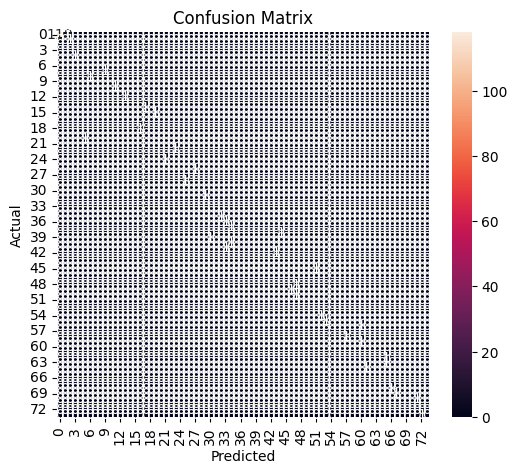

In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

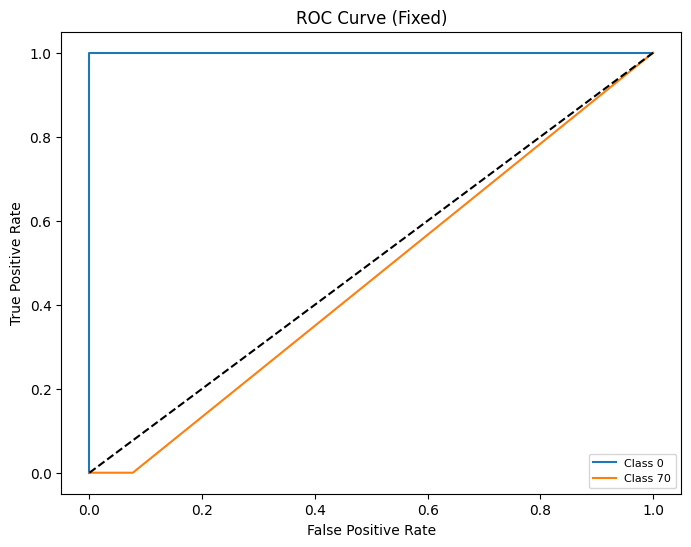

In [39]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Use only classes seen during training
classes = rf.classes_

# Binarize using ONLY trained classes
y_test_bin = label_binarize(y_test, classes=classes)

# Predict probabilities
y_prob = rf.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    # Ensure both classes exist in this slice
    if len(np.unique(y_test_bin[:, i])) > 1:
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f"Class {classes[i]}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Fixed)")
plt.legend(loc="lower right", fontsize=8)
plt.show()

In [40]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

print("R2 Score:", lr.score(X_test, y_test))

R2 Score: 0.9699481467450939


In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       118
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0
          13       0.00      0.00      0.00         1
          18       0.00      0.00      0.00         0
          24       0.00      0.00      0.00         0
          28       0.00      0.00      0.00         1
          29       0.00      0.00      0.00         1
          33       0.00      0.00      0.00         0
          35       0.00      0.00      0.00         1
          37       0.00      0.00      0.00         0
          43       0.00      0.00      0.00         1
          46       0.00      0.00      0.00         0
          47       0.00      0.00      0.00         1
          48       0.00      0.00      0.00         1
          51       0.00      0.00      0.00         0
          52       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

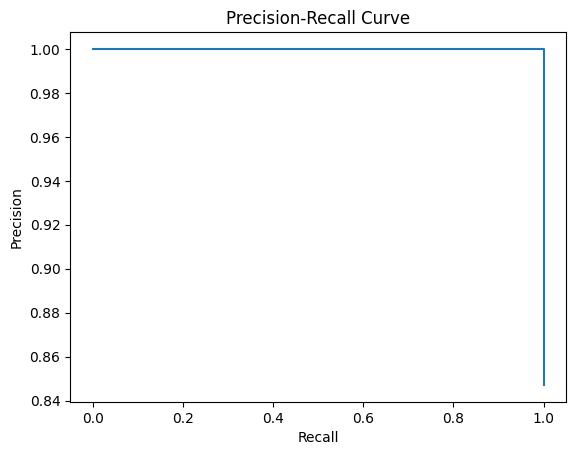

In [23]:
from sklearn.metrics import precision_recall_curve

y_prob = rf.predict_proba(X_test)

precision, recall, _ = precision_recall_curve(y_test, y_prob[:, 0], pos_label=0)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()